In [210]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import hmean
import numpy as np


In [211]:
file_name = "Model_prediction_scores.pkl"  # Name der Datei
file_paths_list = []  # Liste zum Speichern der Pfade

for root, _, files in os.walk("."):  # Durchsuche das aktuelle Verzeichnis und Unterordner
    if file_name in files:
        file_paths_list.append(os.path.join(root, file_name)) 

In [212]:
file_paths_list

['.\\Model_prediction_scores.pkl',
 '.\\Prediction_Classes_Data\\Text\\Model_prediction_scores.pkl',
 '.\\Prediction_Classes_Data\\Theses\\Model_prediction_scores.pkl',
 '.\\Prediction_Data\\Text\\Model_prediction_scores.pkl',
 '.\\Prediction_Data\\Theses\\Model_prediction_scores.pkl',
 '.\\SpaCy_Prediction_Data\\Text\\Model_prediction_scores.pkl',
 '.\\SpaCy_Prediction_Data\\These\\Model_prediction_scores.pkl']

In [213]:
pd.read_pickle('.\\Prediction_Classes_Data\\Text\\Model_prediction_scores.pkl')

,model,lable_text_column,party_text_column,Manifesto_sorted,accuracy,precision,recall,f1
0,paraphrase_multilingual_mpnet_base_v2,These,Text,class prefitted,0.162281,0.228529,0.392523,0.147202
1,paraphrase_multilingual_mpnet_base_v2,These_no_stopwords,Text_no_stopwords,class prefitted,0.197368,0.210020,0.386639,0.176223
2,paraphrase_multilingual_mpnet_base_v2,These_lemmatized,Text_lemmatized,class prefitted,0.162281,0.354382,0.361838,0.148640
3,sbert_hashtag_german_politicians_2021,These,Text,class prefitted,0.280702,0.331905,0.369660,0.243774
4,sbert_hashtag_german_politicians_2021,These_no_stopwords,Text_no_stopwords,class prefitted,0.289474,0.332745,0.376253,0.256797
5,sbert_hashtag_german_politicians_2021,These_lemmatized,Text_lemmatized,class prefitted,0.285088,0.322655,0.357614,0.248823
6,paraphrase_multilingual_MiniLM_L12_v2,These,Text,class prefitted,0.122807,0.236635,0.364486,0.106374
7,paraphrase_multilingual_MiniLM_L12_v2,These_no_stopwords,Text_no_stopwords,class prefitted,0.162281,0.231230,0.377120,0.148697
8,paraphrase_multilingual_MiniLM_L12_v2,These_lemmatized,Text_lemmatized,class prefitted,0.149123,0.214059,0.383178,0.133731


In [214]:
Model_prediction_scores = pd.concat([pd.read_pickle(file_path) for file_path in file_paths_list], ignore_index=True)


In [215]:
Model_prediction_scores.columns


Index(['model', 'lable_text_column', 'party_text_column', 'Manifesto_sorted',
       'accuracy', 'precision', 'recall', 'f1'],
      dtype='object')

In [216]:
Model_prediction_scores['combined_score'] = Model_prediction_scores.apply(lambda row: hmean([row['accuracy'], row['f1']]), axis=1)
#Model_prediction_scores.sort_values(by='combined_score', ascending=False).head(10)

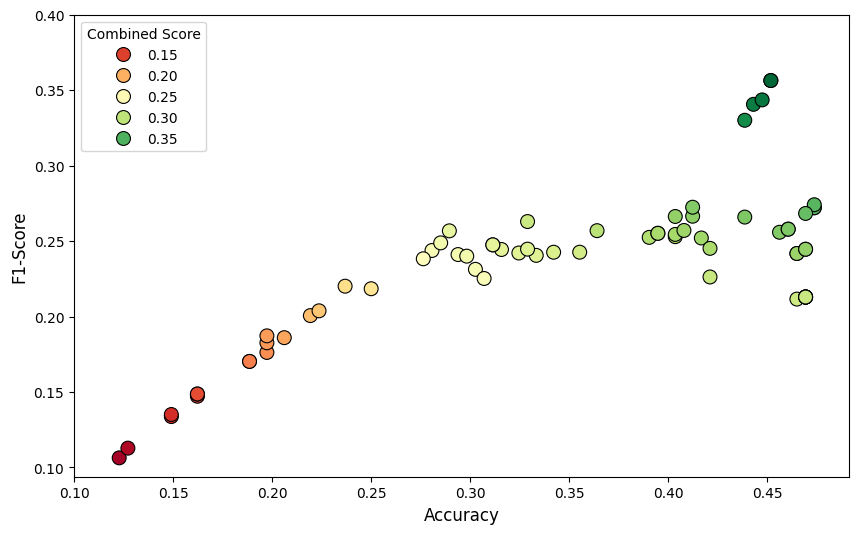

In [217]:
# Erstelle den Scatterplot mit Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='accuracy', y='f1', hue='combined_score', data=Model_prediction_scores, palette='RdYlGn', s=100, edgecolor='black')

# Hinzufügen von Titel und Labels
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(np.arange(0.1, 0.5, 0.05))
plt.yticks(np.arange(0.1, 0.4, 0.05))
# Zeige den Plot an
plt.legend(title='Combined Score')
plt.show()

In [218]:
Model_prediction_scores['model'].unique()

array(['manifestoberta-xlm-roberta-56policy-topics-context',
       'paraphrase_multilingual_mpnet_base_v2',
       'sbert_hashtag_german_politicians_2021',
       'paraphrase_multilingual_MiniLM_L12_v2', 'SpaCy_de_core_news_lg'],
      dtype=object)

In [219]:
model_name_replace_dict = {'manifestoberta-xlm-roberta-56policy-topics-context' : 'manifestoBERTa',
                           'paraphrase_multilingual_mpnet_base_v2' : 'MPnet base v2',
                           'sbert_hashtag_german_politicians_2021' : 'sBERT german politics',
                           'paraphrase_multilingual_MiniLM_L12_v2' : 'MiniLM L12 v2', 
                           'SpaCy_de_core_news_lg': 'SpaCy de lg'}

Model_prediction_scores['model']= Model_prediction_scores['model'].replace(model_name_replace_dict)

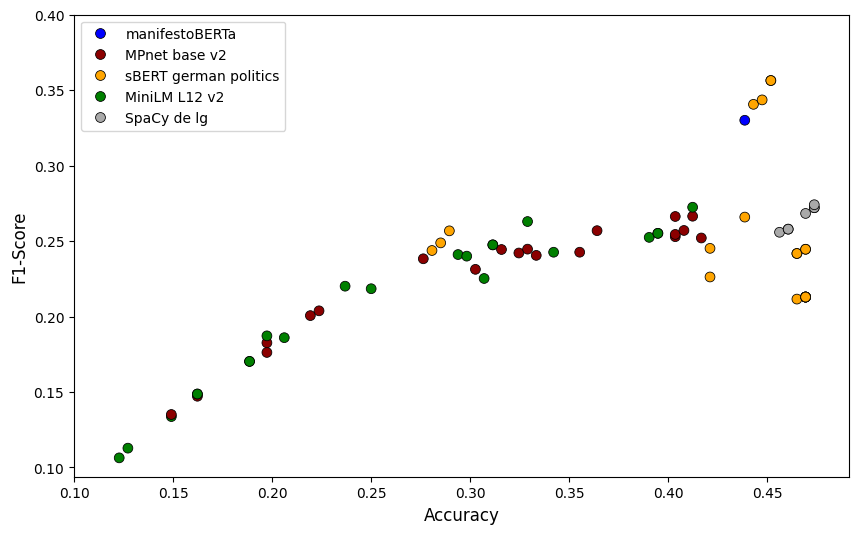

In [220]:

# Erstelle den Scatterplot mit Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='accuracy', 
                y='f1', 
                hue='model',
                #style='model',
                data=Model_prediction_scores, 
                palette=['blue', 'darkred', 'orange', 'green', 'darkgray'], 
                s=50, 
                edgecolor='black')

# Hinzufügen von Titel und Labels
#plt.title('Models', fontsize=16)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(np.arange(0.1, 0.5, 0.05))
plt.yticks(np.arange(0.1, 0.4, 0.05))
# Zeige den Plot an
plt.legend()
plt.show()

In [221]:
Model_prediction_scores['model'].unique()

array(['manifestoBERTa', 'MPnet base v2', 'sBERT german politics',
       'MiniLM L12 v2', 'SpaCy de lg'], dtype=object)

In [222]:
Model_prediction_scores['Manifesto_sorted'].unique()

array(['class prefitted', True, False], dtype=object)

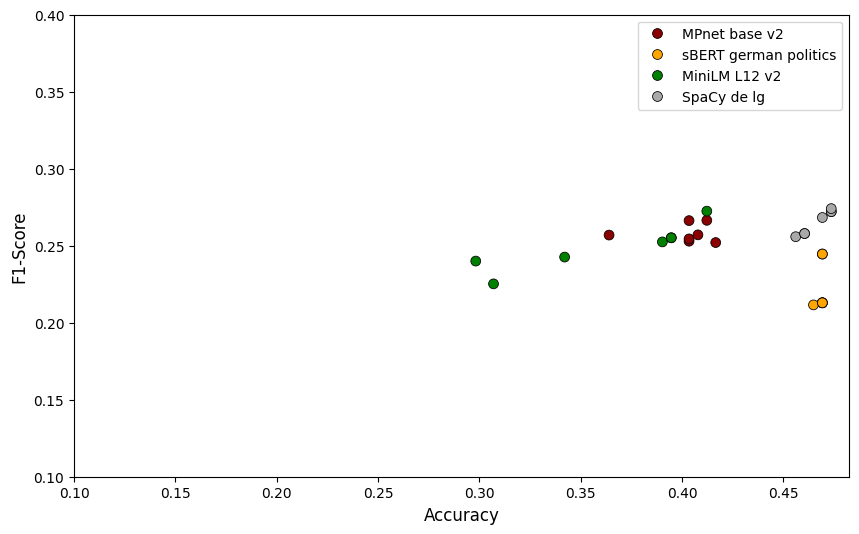

In [223]:
# Erstelle den Scatterplot mit Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='accuracy', 
                y='f1',
                hue= 'model',
                data=Model_prediction_scores[Model_prediction_scores['Manifesto_sorted']==False], 
                palette=['darkred', 'orange', 'green', 'darkgray'], 
                s=50,
                edgecolor='black',
                )

# Hinzufügen von Titel und Labels
#plt.title('manifestoBERTa', fontsize=16)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(np.arange(0.1, 0.5, 0.05))
plt.yticks(np.arange(0.1, 0.4, 0.05))
# Zeige den Plot an
plt.legend()
plt.show()

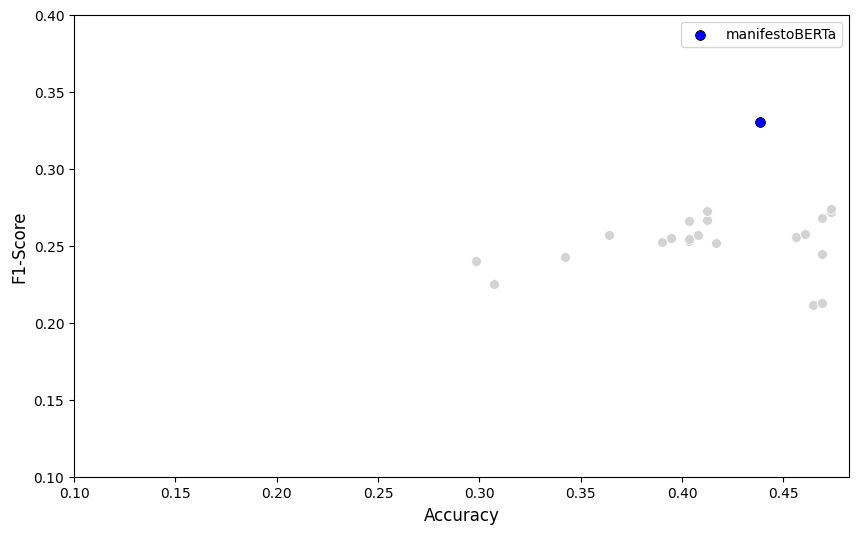

In [224]:
# Erstelle den Scatterplot mit Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='accuracy', 
                y='f1', 
                data=Model_prediction_scores[Model_prediction_scores['Manifesto_sorted']==False], 
                color='lightgray', 
                s=50, 
                )

sns.scatterplot(x='accuracy', 
                y='f1', 
                data=Model_prediction_scores[Model_prediction_scores['model']=='manifestoBERTa'], 
                color='blue', 
                s=50,
                edgecolor='black',
                label='manifestoBERTa'
                )

# Hinzufügen von Titel und Labels
#plt.title('manifestoBERTa', fontsize=16)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(np.arange(0.1, 0.5, 0.05))
plt.yticks(np.arange(0.1, 0.4, 0.05))
# Zeige den Plot an
plt.legend()
plt.show()

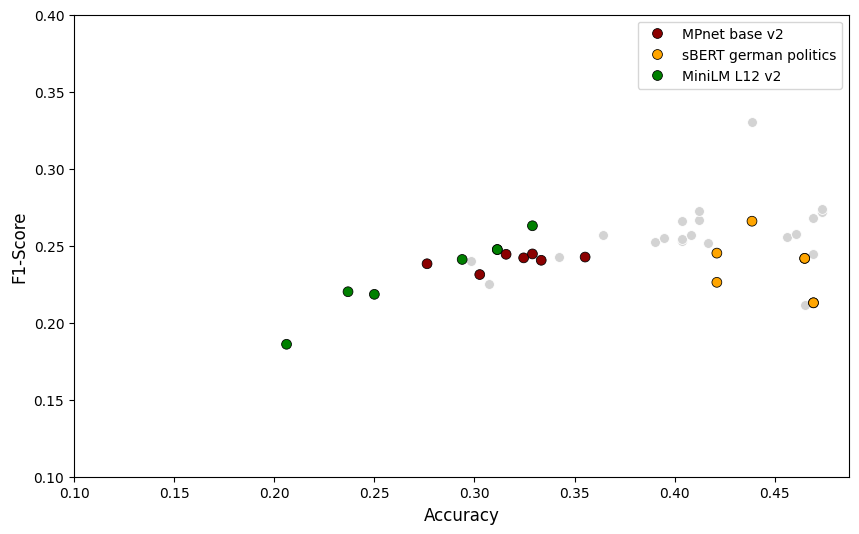

In [225]:
# Erstelle den Scatterplot mit Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='accuracy', 
                y='f1', 
                data=Model_prediction_scores[(Model_prediction_scores['Manifesto_sorted'] == False) | 
                                 (Model_prediction_scores['model'] == 'manifestoBERTa')],  
                color='lightgray', 
                s=50, 
                )

sns.scatterplot(x='accuracy', 
                y='f1', 
                data=Model_prediction_scores[Model_prediction_scores['Manifesto_sorted']==True],
                hue= 'model', 
                palette = ['darkred', 'orange', 'green'], 
                s=50,
                edgecolor='black',
                )

# Hinzufügen von Titel und Labels
#plt.title('manifestoBERTa', fontsize=16)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(np.arange(0.1, 0.5, 0.05))
plt.yticks(np.arange(0.1, 0.4, 0.05))
# Zeige den Plot an
plt.legend()
plt.show()

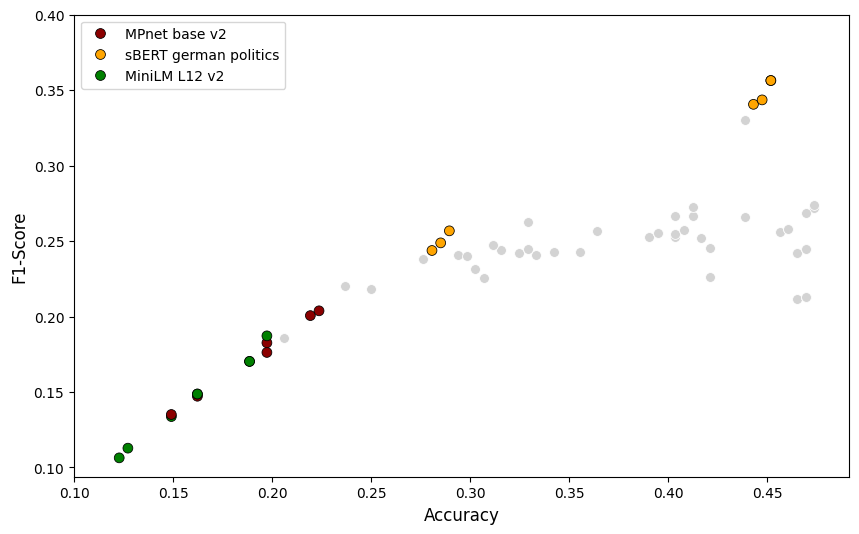

In [226]:
# Erstelle den Scatterplot mit Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='accuracy', 
                y='f1', 
                data=Model_prediction_scores[(Model_prediction_scores['Manifesto_sorted'] != 'class prefitted') | 
                                 (Model_prediction_scores['model'] == 'manifestoBERTa')],  
                color='lightgray', 
                s=50, 
                )

sns.scatterplot(x='accuracy', 
                y='f1', 
                data=Model_prediction_scores[(Model_prediction_scores['Manifesto_sorted'] == 'class prefitted') & 
                                 (Model_prediction_scores['model'] != 'manifestoBERTa')],
                hue= 'model', 
                palette = ['darkred', 'orange', 'green'], 
                s=50,
                edgecolor='black',
                )

# Hinzufügen von Titel und Labels
#plt.title('manifestoBERTa', fontsize=16)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(np.arange(0.1, 0.5, 0.05))
plt.yticks(np.arange(0.1, 0.4, 0.05))
# Zeige den Plot an
plt.legend()
plt.show()

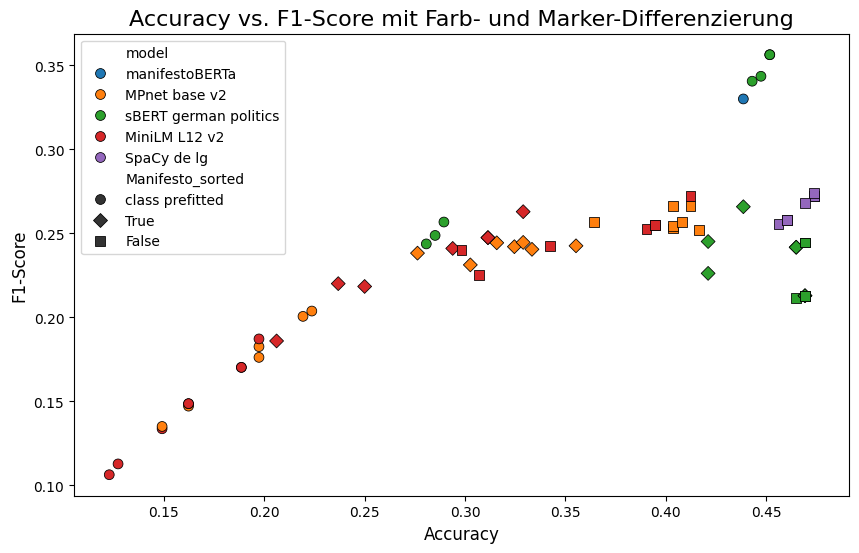

In [227]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 🔹 Seaborn-Plot mit `hue` für Farbe (Manifesto_sorted) und `style` für Marker (model)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='accuracy', 
    y='f1', 
    hue='model',  # Farblich nach Manifesto_sorted unterscheiden
    style='Manifesto_sorted',  # Marker nach Model unterscheiden
    markers={True: 'D', False: 's', 'class prefitted': 'o'},
    data=Model_prediction_scores, 
    palette = sns.color_palette("tab10", 5),
    s=50, 
    edgecolor='black'
)

# 🔹 Hinzufügen von Titel und Labels
plt.title('Accuracy vs. F1-Score mit Farb- und Marker-Differenzierung', fontsize=16)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)

# 🔹 Legende anzeigen
plt.legend()
plt.show()


C:\Users\lnieb\AppData\Local\Temp\ipykernel_12024\168747258.py:8: UserWarning: 
The palette list has fewer values (5) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


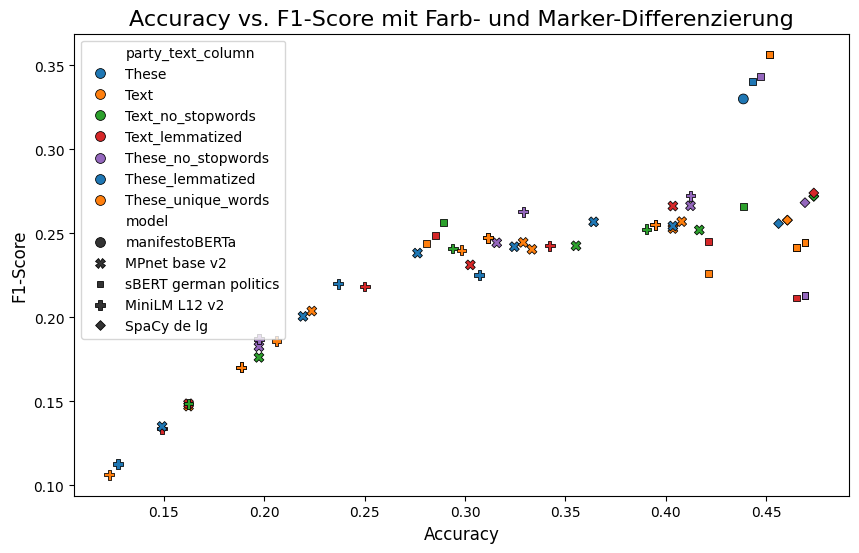

In [228]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 🔹 Seaborn-Plot mit `hue` für Farbe (Manifesto_sorted) und `style` für Marker (model)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='accuracy', 
    y='f1', 
    hue='party_text_column',  # Farblich nach Manifesto_sorted unterscheiden
    style='model',  # Marker nach Model unterscheiden
    data=Model_prediction_scores, 
    palette = sns.color_palette("tab10", 5),
    s=50, 
    edgecolor='black'
)

# 🔹 Hinzufügen von Titel und Labels
plt.title('Accuracy vs. F1-Score mit Farb- und Marker-Differenzierung', fontsize=16)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)

# 🔹 Legende anzeigen
plt.legend()
plt.show()
